# 01 - Exploração dos dados

**Objetivo:** conhecer as radiografias antes de treinar qualquer modelo.

Perguntas que vamos responder:
1. Quantas imagens existem em cada conjunto (`train`, `val`, `test`) e em cada classe?
2. As classes estão balanceadas?
3. Como são as imagens? Todas têm o mesmo tamanho?
4. Existe alguma diferença visível de brilho entre NORMAL e PNEUMONIA?

> Entender os dados evita surpresas e retrabalho.

## 1. Preparação

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# O notebook está em notebooks/, então subimos uma pasta para achar data/
RAIZ = Path("..") / "data" / "chest_xray"
PASTA_FIGURAS = Path("..") / "reports" / "figures"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

CONJUNTOS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]
EXTENSOES = {".jpeg", ".jpg", ".png"}

# Fixa a semente para o sorteio de imagens dar o mesmo resultado sempre
rng = np.random.default_rng(42)

## 2. Lista de todas as imagens

Vamos montar uma tabela (DataFrame do pandas) com **uma linha por imagem**, guardando o conjunto, a classe e o caminho do arquivo. Com isso, contar e filtrar fica simples.

In [2]:
linhas = []
for conjunto in CONJUNTOS:
    for classe in CLASSES:
        for arquivo in sorted((RAIZ / conjunto / classe).iterdir()):
            if arquivo.suffix.lower() in EXTENSOES:
                linhas.append({"conjunto": conjunto, "classe": classe, "caminho": arquivo})

df = pd.DataFrame(linhas)
print(f"Total de imagens: {len(df)}")
df.head()

Total de imagens: 5856


,conjunto,classe,caminho
0,train,NORMAL,../data/chest_xray/train/NORMAL/IM-0115-0001.jpeg
1,train,NORMAL,../data/chest_xray/train/NORMAL/IM-0117-0001.jpeg
2,train,NORMAL,../data/chest_xray/train/NORMAL/IM-0119-0001.jpeg
3,train,NORMAL,../data/chest_xray/train/NORMAL/IM-0122-0001.jpeg
4,train,NORMAL,../data/chest_xray/train/NORMAL/IM-0125-0001.jpeg


## 3. Quantas imagens por conjunto e classe?

In [3]:
contagem = pd.crosstab(df["conjunto"], df["classe"])
contagem = contagem.loc[CONJUNTOS]          # mantém a ordem train, val, test
contagem["total"] = contagem.sum(axis=1)
contagem

classe,NORMAL,PNEUMONIA,total
conjunto,,,
train,1341,3875,5216
val,8,8,16
test,234,390,624


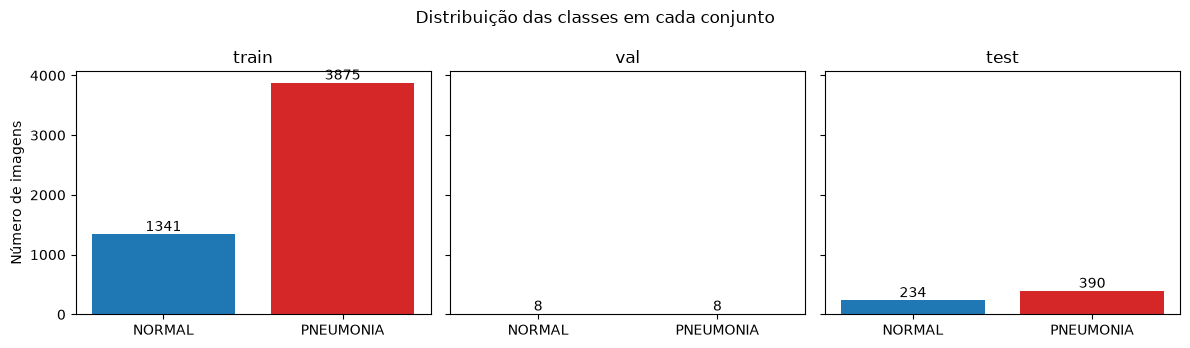

In [4]:
fig, eixos = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for eixo, conjunto in zip(eixos, CONJUNTOS):
    valores = contagem.loc[conjunto, CLASSES]
    barras = eixo.bar(CLASSES, valores, color=["tab:blue", "tab:red"])
    eixo.bar_label(barras)                   # escreve o número em cima de cada barra
    eixo.set_title(conjunto)

eixos[0].set_ylabel("Número de imagens")
fig.suptitle("Distribuição das classes em cada conjunto")
plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "01_distribuicao_classes.png", dpi=120)
plt.show()

In [5]:
# Proporção de cada classe em %
proporcao = (contagem[CLASSES].div(contagem["total"], axis=0) * 100).round(1)
proporcao

classe,NORMAL,PNEUMONIA
conjunto,,
train,25.7,74.3
val,50.0,50.0
test,37.5,62.5


## 4. Como são as imagens?

Sorteamos 5 radiografias de cada classe do conjunto de treino.

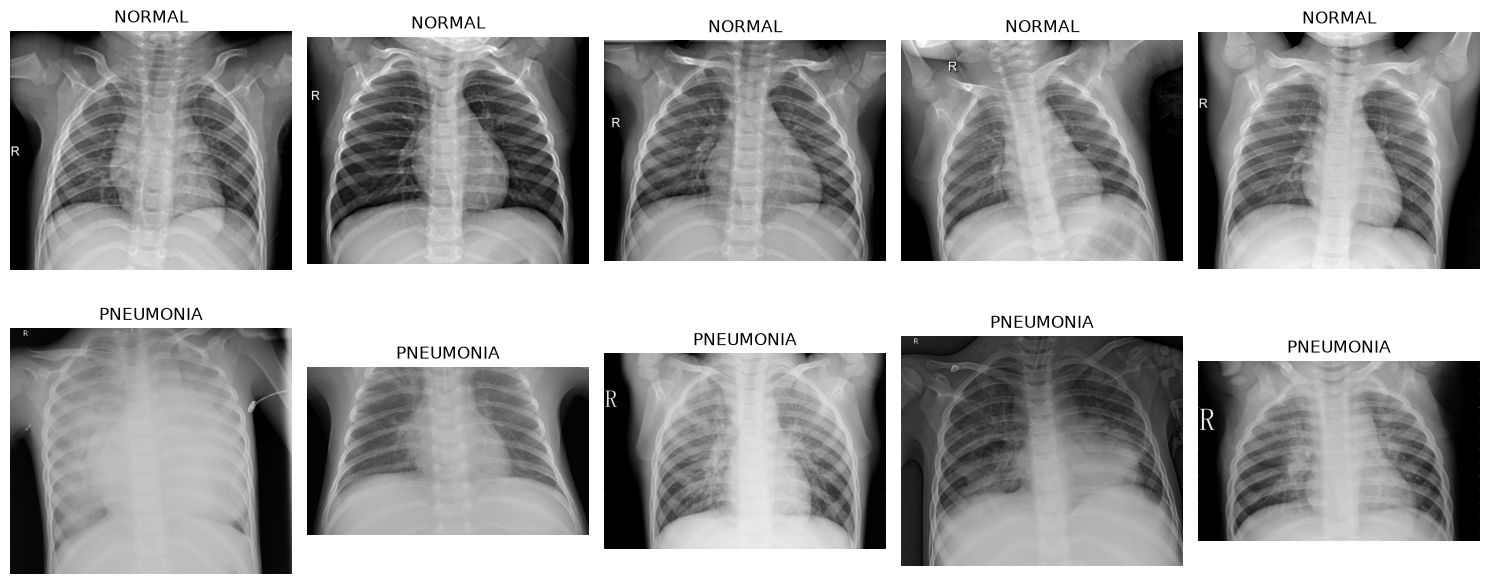

In [6]:
fig, eixos = plt.subplots(2, 5, figsize=(15, 6.5))

for linha, classe in enumerate(CLASSES):
    candidatas = df[(df["conjunto"] == "train") & (df["classe"] == classe)]
    sorteadas = candidatas.sample(5, random_state=42)
    for eixo, caminho in zip(eixos[linha], sorteadas["caminho"]):
        eixo.imshow(Image.open(caminho), cmap="gray")
        eixo.set_title(classe)
        eixo.axis("off")

plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "01_exemplos_imagens.png", dpi=120)
plt.show()

## 5. Tamanho e formato das imagens

Uma CNN (o tipo de rede que vamos usar para reconhecer as imagens) só funciona bem se todas as imagens entrarem com o **mesmo tamanho**. Vamos ver se é o caso aqui.


In [7]:
larguras, alturas, modos = [], [], []
for caminho in df["caminho"]:
    with Image.open(caminho) as img:
        larguras.append(img.width)
        alturas.append(img.height)
        modos.append(img.mode)      # "L" = tons de cinza, "RGB" = colorida

df["largura"] = larguras
df["altura"] = alturas
df["modo"] = modos

df[["largura", "altura"]].describe().round(0)

,largura,altura
count,5856.0,5856.0
mean,1328.0,971.0
std,364.0,383.0
min,384.0,127.0
25%,1056.0,688.0
50%,1281.0,888.0
75%,1560.0,1187.0
max,2916.0,2713.0


In [8]:
print("Modos de cor (L = cinza, RGB = colorida):")
print(df["modo"].value_counts())

Modos de cor (L = cinza, RGB = colorida):
modo
L      5573
RGB     283
Name: count, dtype: int64


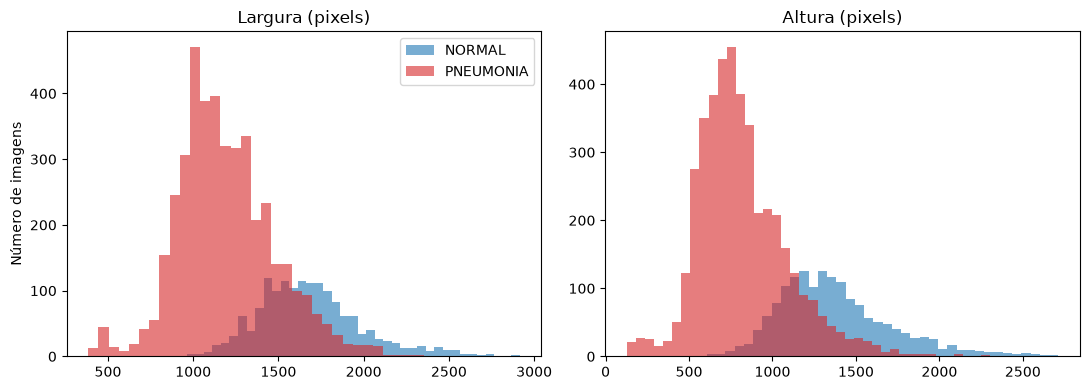

In [9]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

for classe, cor in zip(CLASSES, ["tab:blue", "tab:red"]):
    parte = df[df["classe"] == classe]
    eixos[0].hist(parte["largura"], bins=40, alpha=0.6, label=classe, color=cor)
    eixos[1].hist(parte["altura"], bins=40, alpha=0.6, label=classe, color=cor)

eixos[0].set_title("Largura (pixels)")
eixos[1].set_title("Altura (pixels)")
eixos[0].set_ylabel("Número de imagens")
eixos[0].legend()
plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "01_tamanhos.png", dpi=120)
plt.show()

## 6. Brilho das imagens

Cada pixel vai de 0 (preto) a 255 (branco). Vamos calcular o **brilho médio** de uma amostra de 300 imagens por classe (do treino) e ver se as classes se diferenciam.

Isso é só para entender os dados. Se uma classe fosse sistematicamente mais clara por causa do aparelho de raio-X e não da doença, o modelo poderia aprender esse "atalho".

In [10]:
def brilho_medio(caminho):
    # Converte para tons de cinza ("L") e calcula a média dos pixels
    with Image.open(caminho) as img:
        return np.asarray(img.convert("L")).mean()

resultados = {}
for classe in CLASSES:
    candidatas = df[(df["conjunto"] == "train") & (df["classe"] == classe)]
    amostra = candidatas.sample(300, random_state=42)
    resultados[classe] = [brilho_medio(c) for c in amostra["caminho"]]

brilho = pd.DataFrame(resultados)
brilho.describe().round(1)

,NORMAL,PNEUMONIA
count,300.0,300.0
mean,123.0,125.3
std,13.0,20.8
min,90.1,69.6
25%,114.5,111.7
50%,123.1,126.4
75%,131.4,141.2
max,162.3,176.4


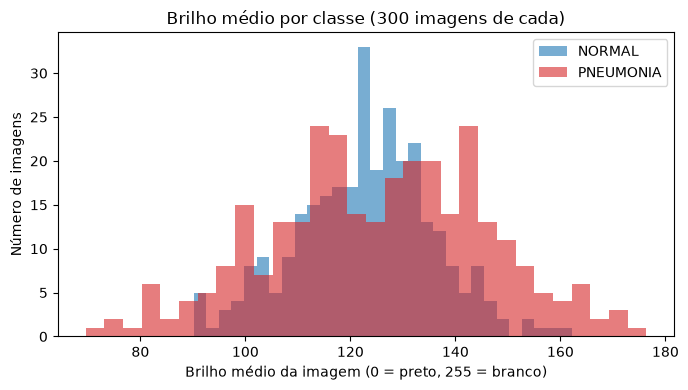

In [11]:
fig, eixo = plt.subplots(figsize=(7, 4))
for classe, cor in zip(CLASSES, ["tab:blue", "tab:red"]):
    eixo.hist(brilho[classe], bins=30, alpha=0.6, label=classe, color=cor)
eixo.set_xlabel("Brilho médio da imagem (0 = preto, 255 = branco)")
eixo.set_ylabel("Número de imagens")
eixo.set_title("Brilho médio por classe (300 imagens de cada)")
eixo.legend()
plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "01_brilho.png", dpi=120)
plt.show()

## 7. Conclusões

O que descobrimos e o que isso muda no projeto:

1. **Classes desbalanceadas no treino.** Há 1341 imagens NORMAL (25,7%) contra 3875 PNEUMONIA (74,3%). Um modelo que respondesse sempre "pneumonia", sem nem olhar a imagem, já acertaria cerca de 74% das vezes — por isso o simples "% de acerto" não basta para dizer se um modelo é bom. Vamos usar métricas melhores mais à frente (explicadas com calma no notebook 3) e dar mais peso aos erros na classe rara durante o treino.
2. **O `val` original é minúsculo.** Tem só 16 imagens (8 de cada). Qualquer resultado calculado com tão pouco dado varia muito de uma imagem para outra, então não dá para confiar nele. Vamos criar uma validação nova, maior, a partir do `train`.
3. **A proporção do `test` é diferente da do `train`** (37,5% NORMAL contra 25,7%). Isso não é um erro, só precisamos lembrar disso na hora de comparar os resultados.
4. **Os tamanhos variam muito.** A largura vai de 384 a 2916 pixels e a altura de 127 a 2713. Vamos deixar tudo do mesmo tamanho (por exemplo 224 x 224) no pré-processamento.
5. **Quase todas as imagens estão em tons de cinza** (5573 de 5856); 283 estão coloridas (RGB). Vamos converter todas para o mesmo formato ao carregar.
6. **O brilho médio é parecido nas duas classes** (média de 123,0 em NORMAL e 125,3 em PNEUMONIA), mas em PNEUMONIA o brilho varia mais de imagem para imagem (essa variação é maior: 20,8 contra 13,0). As imagens de pneumonia tendem a ter regiões mais claras nos pulmões, como dá para ver nos exemplos.
